# ── Generate grouped main basin shapefile for Alexis ──

In [1]:
# Imports
import os, pickle, calendar
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import warnings
warnings.filterwarnings('ignore')

In [2]:
#
# Implements Alexis's 4-step workflow:
# Step 1: Find CAMELS polygons that contain at least one RGI glacier centroid
# Step 2: Filter by jerarquia to keep only highest-level basin per river system
# Step 3: (Visual check in QGIS/ArcGIS — do manually after export)
# Step 4: Compute basin area and glacier area, apply 1% minimum threshold
#
# Output: shapefile ready to share with Alexis for review

BASE        = '/Users/milliespencer/Desktop/CR2_OGGM_Paper'
FILTRADO    = f'{BASE}/Camels_filtrado'
BOUNDS_PATH = (f'{BASE}/Full_CAMELS_all_basins/CAMELS_CL_v202201/'
               f'camels_cl_boundaries/camels_cl_boundaries.shp')
RGI_PATH    = (f'{BASE}/files_chile_OGGM_climate_comparison/'
               f'RGI_BNA_Clusters.csv')
OUT_PATH    = f'{BASE}/Output/main_basins_for_alexis.shp'

GLAC_THRESHOLD_PCT = 1.0   # Alexis recommends 1% minimum glacier cover

# ── Load data ─────────────────────────────────────────────────────────────
print('Loading data...')
bounds = gpd.read_file(BOUNDS_PATH)
bounds['gauge_id'] = bounds['gauge_id'].astype(str)
if bounds.crs.to_epsg() != 4326:
    bounds = bounds.to_crs(epsg=4326)

rgi = pd.read_csv(RGI_PATH)
gdf_rgi = gpd.GeoDataFrame(
    rgi,
    geometry=gpd.points_from_xy(rgi.CenLon, rgi.CenLat),
    crs='EPSG:4326'
)

print(f'CAMELS polygons: {len(bounds)}')
print(f'RGI glaciers:    {len(gdf_rgi)}')

# ── Step 1: Find polygons containing at least one glacier centroid ─────────
print('\nStep 1: Spatial join — glacier centroids to basin polygons...')
joined = gpd.sjoin(gdf_rgi, bounds, how='inner', predicate='within')

glacierized_gauge_ids = set(joined['gauge_id'].unique())
print(f'Polygons containing at least one glacier: {len(glacierized_gauge_ids)}')

# Compute glacier area and count per polygon
glacier_stats = (joined.groupby('gauge_id')
                 .agg(n_glaciers  =('RGIId',   'count'),
                      glacier_area=('Area',     'sum'),
                      clusters    =('Cluster',  lambda x: list(x.unique())))
                 .reset_index())

# ── Step 2: Filter by jerarquia ────────────────────────────────────────────
print('\nStep 2: Loading jerarquia and filtering to main basins...')
hier = gpd.read_file(f'{FILTRADO}/Camels_jerarquia.shp')
hier['gauge_id'] = hier['gauge_id'].astype(str)
if hier.crs.to_epsg() != 4326:
    hier = hier.to_crs(epsg=4326)

print(f'Jerarquia unique values: {sorted(hier["jerarquia"].unique())}')
print(f'Total polygons in jerarquia shapefile: {len(hier)}')

# Keep only jerarquia=0 (main basins, no sub-sub-basins)
main_basins = hier[hier['jerarquia'] == 0].copy()
print(f'Main basins (jerarquia=0): {len(main_basins)}')

# Keep only those that contain glaciers
main_glacierized = main_basins[
    main_basins['gauge_id'].isin(glacierized_gauge_ids)].copy()
print(f'Main basins with glaciers: {len(main_glacierized)}')

# ── Step 4: Compute areas and apply 1% threshold ──────────────────────────
print('\nStep 4: Computing areas and applying glacier threshold...')

# Reproject to UTM for accurate area calculation
main_utm = main_glacierized.to_crs(epsg=32719)
main_utm['basin_area_km2'] = main_utm.geometry.area / 1e6

# Merge glacier stats
main_utm = main_utm.merge(glacier_stats, on='gauge_id', how='left')
main_utm['glacier_area_km2'] = main_utm['glacier_area'].fillna(0)
main_utm['glacier_pct']      = (main_utm['glacier_area_km2'] /
                                 main_utm['basin_area_km2'] * 100)

# Apply 1% threshold
before = len(main_utm)
main_final = main_utm[main_utm['glacier_pct'] >= GLAC_THRESHOLD_PCT].copy()
after  = len(main_final)
print(f'Before 1% threshold: {before} basins')
print(f'After  1% threshold: {after} basins')
print(f'Removed: {before - after} basins below 1% glacier cover')

# ── Summary by cluster ─────────────────────────────────────────────────────
print('\nSummary:')
print(f'{"gauge_id":12s} {"n_glaciers":12s} {"basin_km2":12s} '
      f'{"glac_km2":10s} {"glac_pct":10s} {"clusters"}')
print('-' * 80)
for _, row in (main_final
               .sort_values('gauge_id')
               .iterrows()):
    print(f'{row["gauge_id"]:12s} {row["n_glaciers"]:12.0f} '
          f'{row["basin_area_km2"]:12.1f} '
          f'{row["glacier_area_km2"]:10.1f} '
          f'{row["glacier_pct"]:10.2f}% '
          f'{row["clusters"]}')

print(f'\nTotal basins for Alexis: {len(main_final)}')
print(f'Total glacier area:      {main_final["glacier_area_km2"].sum():.1f} km²')
print(f'Total basin area:        {main_final["basin_area_km2"].sum():.1f} km²')

# ── Export shapefile ───────────────────────────────────────────────────────
# Reproject back to WGS84 for sharing
main_export = main_final.to_crs(epsg=4326)

# Clean up columns for export
keep_cols = ['gauge_id', 'gauge_name', 'jerarquia',
             'n_glaciers', 'basin_area_km2',
             'glacier_area_km2', 'glacier_pct', 'geometry']
keep_cols = [c for c in keep_cols if c in main_export.columns]
main_export = main_export[keep_cols]

main_export.to_file(OUT_PATH)
print(f'\nSaved: {OUT_PATH}')
print('Ready to share with Alexis for Step 3 visual review.')

Loading data...
CAMELS polygons: 516
RGI glaciers:    13246

Step 1: Spatial join — glacier centroids to basin polygons...
Polygons containing at least one glacier: 266

Step 2: Loading jerarquia and filtering to main basins...
Jerarquia unique values: [0.0]
Total polygons in jerarquia shapefile: 146
Main basins (jerarquia=0): 146
Main basins with glaciers: 61

Step 4: Computing areas and applying glacier threshold...
Before 1% threshold: 61 basins
After  1% threshold: 24 basins
Removed: 37 basins below 1% glacier cover

Summary:
gauge_id     n_glaciers   basin_km2    glac_km2   glac_pct   clusters
--------------------------------------------------------------------------------
10523002              414       8851.6      229.1       2.59% ['WA2']
10704002              389       8682.4      128.6       1.48% ['WA2']
11040001              640      12429.1      325.4       2.62% ['WA2']
11130001               26        163.6       57.3      35.01% ['WA2']
11147001              175       5

## trying 1% glacierized threshold for basins

Columns: ['gauge_id', 'gauge_name', 'jerarquia', 'n_glaciers', 'basin_area', 'glacier_ar', 'glacier_pc', 'geometry']

First few rows of cluster-related columns:
  gauge_id: ['3041005', '5707002', '5710001']
  gauge_name: ['Rio Lamas En El Salto', 'Rio Colorado Antes Junta Rio Maipo', 'Rio Maipo En El Manzano']
  jerarquia: [0.0, 0.0, 0.0]
  n_glaciers: [90, 92, 259]
  basin_area: [2271.847850075474, 1662.7976515094326, 4839.04678575912]
  glacier_ar: [28.403, 153.782, 350.65500000000003]
  glacier_pc: [1.250215765948253, 9.248389295017455, 7.246365152573977]

Cluster assignments:
    gauge_id cluster
0    3041005     DA1
1    5707002     DA2
2    5710001     DA3
3    5721001     DA2
4    5748001     DA3
5    6019003     DA3
6    6034001     DA3
7    6035001     DA3
8    9404001     WA1
9    9437002     WA1
10  10523002     WA2
11  10704002     WA2
12  11040001     WA2
13  11130001     WA2
14  11147001     WA2
15  11151001     WA2
16  11342001     WA2
17  11405001     WA2
18  11536004  

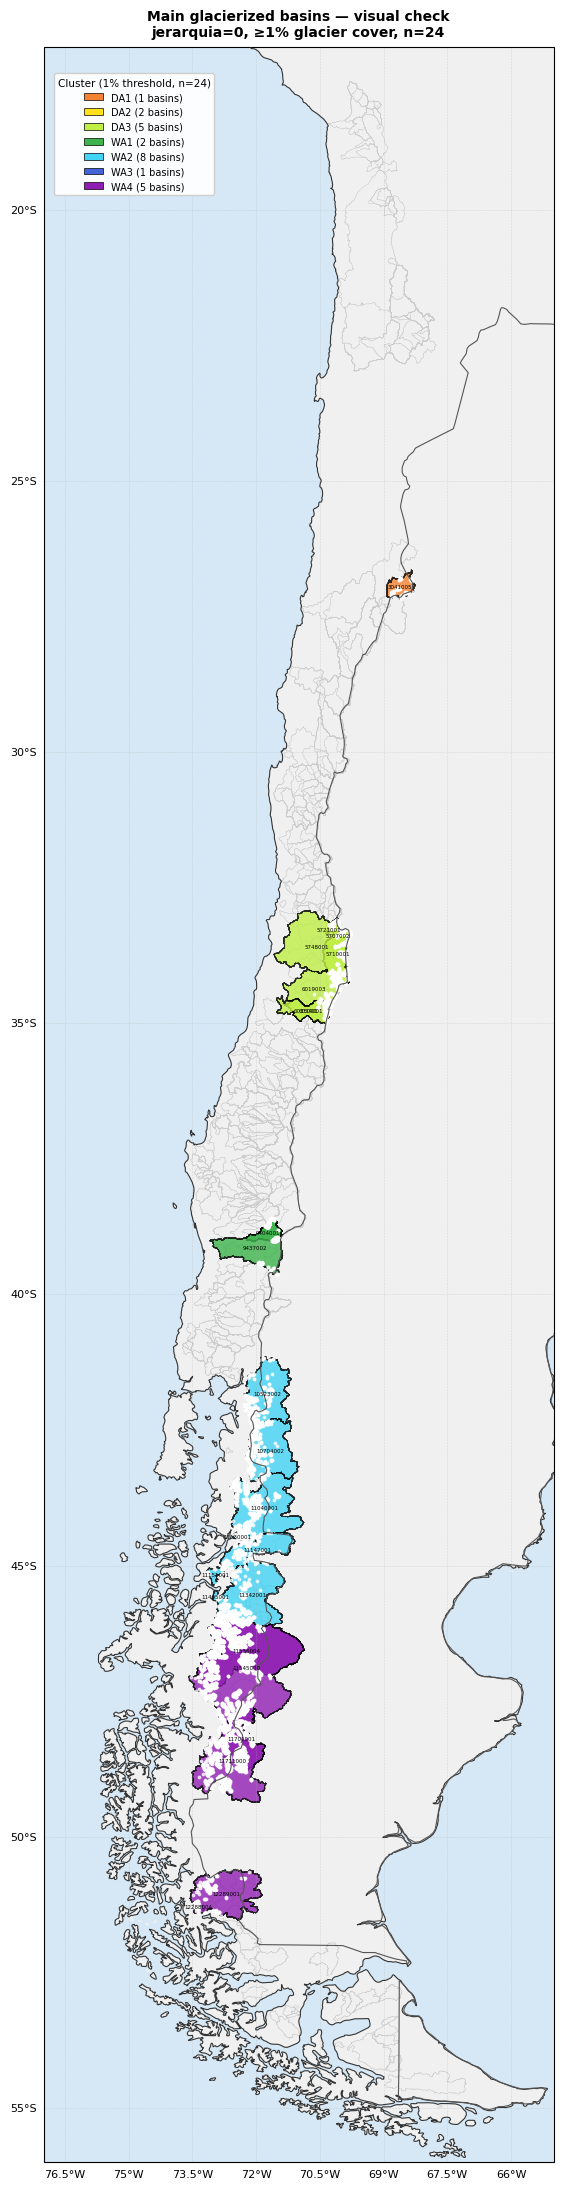

Saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/main_basins_visual_check.png


In [3]:
# ── Quick visual check of main_basins_for_alexis.shp ─────────────────────

BASE     = '/Users/milliespencer/Desktop/CR2_OGGM_Paper'

# ── Load data ──────────────────────────────────────────────────────────────
main = gpd.read_file(f'{BASE}/Output/main_basins_for_alexis.shp')
if main.crs.to_epsg() != 4326:
    main = main.to_crs(epsg=4326)

# Debug: see what columns and values we actually have
print('Columns:', main.columns.tolist())
print('\nFirst few rows of cluster-related columns:')
for col in main.columns:
    if col != 'geometry':
        print(f'  {col}: {main[col].iloc[:3].tolist()}')

# Load all CAMELS boundaries for context
bounds_path = (f'{BASE}/Full_CAMELS_all_basins/CAMELS_CL_v202201/'
               f'camels_cl_boundaries/camels_cl_boundaries.shp')
bounds = gpd.read_file(bounds_path).to_crs(epsg=4326)

# Load RGI glaciers
rgi = pd.read_csv(f'{BASE}/files_chile_OGGM_climate_comparison/'
                  f'RGI_BNA_Clusters.csv')
gdf_rgi = gpd.GeoDataFrame(
    rgi,
    geometry=gpd.points_from_xy(rgi.CenLon, rgi.CenLat),
    crs='EPSG:4326'
)

# ── Reassign cluster from RGI spatial join (more reliable than saved field) 
# Do a fresh spatial join to get cluster per basin
joined = gpd.sjoin(gdf_rgi[['RGIId','Cluster','geometry']],
                   main[['gauge_id','geometry']],
                   how='inner', predicate='within')

# Get dominant cluster per basin (most glaciers)
dominant_cluster = (joined.groupby('gauge_id')['Cluster']
                    .agg(lambda x: x.value_counts().index[0])
                    .reset_index()
                    .rename(columns={'Cluster': 'cluster'}))

main = main.merge(dominant_cluster, on='gauge_id', how='left')
print('\nCluster assignments:')
print(main[['gauge_id','cluster']].to_string())

# ── Cluster colors ─────────────────────────────────────────────────────────
cluster_colors = {
    'OT3': '#e6194b', 'DA1': '#f58231', 'DA2': '#ffe119',
    'DA3': '#bfef45', 'WA1': '#3cb44b', 'WA2': '#42d4f4',
    'WA3': '#4363d8', 'WA4': '#911eb4', 'WA5': '#f032e6',
    'WA6': '#01665e'
}
main['color'] = main['cluster'].map(cluster_colors).fillna('#cccccc')

# ── Figure ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 22))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([-77, -65, -56, -17], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.OCEAN, facecolor='#d6e8f5', zorder=0)
ax.add_feature(cfeature.LAND,  facecolor='#f0f0f0', zorder=0)

# All CAMELS boundaries — light grey context
bounds.plot(ax=ax, facecolor='none', edgecolor='#cccccc',
            linewidth=0.3, zorder=1)

# Main basins colored by cluster — plot each separately
for cl, color in cluster_colors.items():
    subset = main[main['cluster'] == cl]
    if len(subset) == 0:
        continue
    subset.plot(ax=ax,
                facecolor=color,
                edgecolor='k',
                linewidth=0.6,
                alpha=0.8,
                zorder=2)

# Any unassigned basins
unassigned = main[main['cluster'].isna()]
if len(unassigned):
    unassigned.plot(ax=ax, facecolor='#cccccc',
                    edgecolor='k', linewidth=0.4,
                    alpha=0.6, zorder=2)

# Glacier centroids inside main basins
glaciers_in = gpd.sjoin(gdf_rgi, main[['gauge_id','geometry']],
                         how='inner', predicate='within')
ax.scatter(glaciers_in.CenLon, glaciers_in.CenLat,
           s=3, c='white', alpha=0.7, zorder=3,
           transform=ccrs.PlateCarree())

# Coastline
ax.add_feature(cfeature.COASTLINE, linewidth=0.8,
               edgecolor='#333333', zorder=4)

# Argentina border
try:
    world = gpd.read_file(
        'https://naturalearth.s3.amazonaws.com/50m_cultural/'
        'ne_50m_admin_0_countries.zip')
    world[world['NAME'] == 'Argentina'].plot(
        ax=ax, facecolor='none', edgecolor='#555555',
        linewidth=0.8, zorder=4,
        transform=ccrs.PlateCarree())
except Exception:
    pass

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.4,
                  alpha=0.4, linestyle='--')
gl.top_labels   = False
gl.right_labels = False
gl.xlabel_style = {'size': 8}
gl.ylabel_style = {'size': 8}

# Basin labels
for _, row in main.iterrows():
    centroid = row.geometry.centroid
    name = str(row.get('gauge_nam', row['gauge_id']))[:18]
    ax.text(centroid.x, centroid.y, name,
            fontsize=4, ha='center', va='center',
            color='k', zorder=5,
            transform=ccrs.PlateCarree())

# Legend
legend_handles = []
for cl in ['OT3','DA1','DA2','DA3','WA1','WA2','WA3','WA4','WA5','WA6']:
    n = (main['cluster'] == cl).sum()
    if n == 0:
        continue
    legend_handles.append(mpatches.Patch(
        facecolor=cluster_colors[cl],
        edgecolor='k', linewidth=0.5,
        label=f'{cl} ({n} basins)'))

ax.legend(handles=legend_handles,
          loc='upper left',
          fontsize=7,
          framealpha=0.93,
          title=f'Cluster (1% threshold, n={len(main)})',
          title_fontsize=7.5,
          bbox_to_anchor=(0.01, 0.99))

ax.set_title(f'Main glacierized basins — visual check\n'
             f'jerarquia=0, ≥1% glacier cover, n={len(main)}',
             fontsize=10, fontweight='bold', pad=8)

plt.tight_layout()
out = f'{BASE}/Output/main_basins_visual_check.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

## huh very few basins left... retrying with just a 0.1 or 0.5% glacier threshold instead of 1%:

In [4]:
# ── GROUPED BASIN ANALYSIS ────────────────────────────────────────────────

BASE        = '/Users/milliespencer/Desktop/CR2_OGGM_Paper'
OUTPUT_ROOT = f'{BASE}/Output'
CAMELS_FULL = f'{BASE}/Full_CAMELS_all_basins/CAMELS_CL_v202201'
RGI_PATH    = (f'{BASE}/files_chile_OGGM_climate_comparison/'
               f'RGI_BNA_Clusters.csv')
FILTRADO    = f'{BASE}/Camels_filtrado'
BOUNDS_PATH = f'{CAMELS_FULL}/camels_cl_boundaries/camels_cl_boundaries.shp'
OUT_DIR_GRP = f'{OUTPUT_ROOT}/grouped_basin_results'
os.makedirs(OUT_DIR_GRP, exist_ok=True)

# GLAC_THRESHOLD_PCT = 0.5
GLAC_THRESHOLD_PCT = 0.1
LAT_BOUNDARY       = -38.0
SUMMER_THRESHOLD   = 0.70
WINTER_THRESHOLD   = 0.50
YEARS              = list(range(2000, 2020))
CLUSTERS           = ['OT3','DA1','DA2','DA3','WA1',
                      'WA2','WA3','WA4','WA5','WA6']
DATASETS           = {'CR2MET': 'TC', 'ERA5': 'ERA5', 'CRU': 'CRU'}
WATER_DENSITY      = 1000
YEAR_OFFSET        = 1

# ── Step 1: Load shapefiles and RGI ───────────────────────────────────────
print('Loading shapefiles...')
bounds = gpd.read_file(BOUNDS_PATH)
bounds['gauge_id'] = bounds['gauge_id'].astype(str)
if bounds.crs.to_epsg() != 4326:
    bounds = bounds.to_crs(epsg=4326)

hier = gpd.read_file(f'{FILTRADO}/Camels_jerarquia.shp')
hier['gauge_id'] = hier['gauge_id'].astype(str)
if hier.crs.to_epsg() != 4326:
    hier = hier.to_crs(epsg=4326)

rgi = pd.read_csv(RGI_PATH)
gdf_rgi = gpd.GeoDataFrame(
    rgi,
    geometry=gpd.points_from_xy(rgi.CenLon, rgi.CenLat),
    crs='EPSG:4326'
)

print(f'CAMELS polygons:    {len(bounds)}')
print(f'Jerarquia polygons: {len(hier)}')
print(f'RGI glaciers:       {len(gdf_rgi)}')

# ── Step 2: Get jerarquia=0 main basins ───────────────────────────────────
main_basins = hier[hier['jerarquia'] == 0].copy()
print(f'Main basins (jerarquia=0): {len(main_basins)}')

# ── Step 3: Spatial join — RGI centroids to main basin polygons ───────────
print('\nSpatial join: RGI centroids to main basins...')
joined = gpd.sjoin(gdf_rgi, main_basins[['gauge_id','geometry']],
                   how='inner', predicate='within')

glacier_stats = (joined.groupby('gauge_id')
                 .agg(n_glaciers  =('RGIId',  'count'),
                      glacier_area=('Area',    'sum'),
                      rgi_ids     =('RGIId',   list),
                      clusters    =('Cluster', lambda x:
                                    sorted(x.unique().tolist())))
                 .reset_index())

# ── Step 4: Compute basin areas and apply threshold ───────────────────────
main_utm = main_basins.to_crs(epsg=32719).copy()
main_utm['basin_area_km2'] = main_utm.geometry.area / 1e6
main_utm = main_utm.merge(glacier_stats, on='gauge_id', how='left')
main_utm['glacier_area_km2'] = main_utm['glacier_area'].fillna(0)
main_utm['rgi_ids']  = main_utm['rgi_ids'].fillna('').apply(
    lambda x: x if isinstance(x, list) else [])
main_utm['clusters'] = main_utm['clusters'].fillna('').apply(
    lambda x: x if isinstance(x, list) else [])
main_utm['glacier_pct'] = (main_utm['glacier_area_km2'] /
                            main_utm['basin_area_km2'] * 100)

main_glacierized = main_utm[
    main_utm['glacier_pct'] >= GLAC_THRESHOLD_PCT].copy()
main_glacierized = main_glacierized.to_crs(epsg=4326)
print(f'Main basins >= {GLAC_THRESHOLD_PCT}% glacier: {len(main_glacierized)}')

# ── Step 5: lat/lon from geometry, names already in hier ──────────────────
# main_glacierized came from hier so gauge_name is already there
# Just compute centroids
centroids = main_glacierized.geometry.centroid
main_glacierized['cen_lat'] = centroids.y
main_glacierized['cen_lon'] = centroids.x

# Confirm gauge_name is present
print('gauge_name in main_glacierized:',
      'gauge_name' in main_glacierized.columns)
print('Sample names:',
      main_glacierized['gauge_name'].head(3).tolist())

# ── Step 6: Build GAUGE_INFO_GROUPED ──────────────────────────────────────
GAUGE_INFO_GROUPED = {}
for _, row in main_glacierized.iterrows():
    gid = str(row['gauge_id'])
    # gauge_name: prefer hier name, fall back to gauge_id
    name = str(row.get('gauge_name', gid))
    if name == 'nan':
        name = gid
    GAUGE_INFO_GROUPED[gid] = {
        'gauge_name':       name,
        'rgi_ids':          row['rgi_ids'],
        'n_glaciers':       int(row['n_glaciers'])
                            if not pd.isna(row['n_glaciers']) else 0,
        'glacier_area_km2': float(row['glacier_area_km2']),
        'basin_area_km2':   float(row['basin_area_km2']),
        'clusters':         row['clusters'],
        'cen_lat':          float(row['cen_lat']),
        'cen_lon':          float(row['cen_lon']),
    }

print(f'\nGAUGE_INFO_GROUPED: {len(GAUGE_INFO_GROUPED)} basins')
for gid, info in sorted(GAUGE_INFO_GROUPED.items(),
                         key=lambda x: x[1]['cen_lat'], reverse=True):
    pct = info['glacier_area_km2'] / info['basin_area_km2'] * 100
    print(f'  {gid:12s} {info["gauge_name"][:35]:35s} '
          f'lat={info["cen_lat"]:6.1f} '
          f'glac={info["glacier_area_km2"]:7.1f} km² ({pct:.1f}%) '
          f'clusters={info["clusters"]}')

# ── Step 7: Load daily Q and apply completeness filter ────────────────────
print('\nLoading daily Q data...')
q_day = pd.read_csv(f'{CAMELS_FULL}/q_m3s_day.csv', parse_dates=['date'])
q_day = q_day[(q_day['year'] >= 1999) & (q_day['year'] <= 2019)].copy()
print(f'Daily Q: {len(q_day)} rows')

def days_in_month(year, month):
    return calendar.monthrange(year, month)[1]

def month_completeness(col, year, month):
    mask = (q_day['year'] == year) & (q_day['month'] == month)
    vals = col[mask]
    if len(vals) == 0:
        return 0.0
    return (vals.notna() & (vals >= 0)).sum() / days_in_month(year, month)

def assess_completeness(gauge_id, cen_lat):
    if gauge_id not in q_day.columns:
        return {'passes': False, 'complete_years': [],
                'reason': 'no Q column'}
    col = q_day[gauge_id]
    complete_years = []
    for year in range(2000, 2020):
        summer_fracs = [
            month_completeness(col, year-1, 12),
            month_completeness(col, year, 1),
            month_completeness(col, year, 2),
            month_completeness(col, year, 3),
            month_completeness(col, year, 4),
        ]
        winter_fracs = [month_completeness(col, year, mo)
                        for mo in [5,6,7,8,9,10,11]]
        if (all(f >= SUMMER_THRESHOLD for f in summer_fracs) and
                sum(f >= WINTER_THRESHOLD for f in winter_fracs) >= 4):
            complete_years.append(year)
    n_pre  = sum(1 for y in complete_years if y <= 2009)
    n_post = sum(1 for y in complete_years if y >= 2010)
    n_tot  = len(complete_years)
    passes = ((n_pre >= 5 and n_post >= 5)
              if cen_lat > LAT_BOUNDARY else n_tot >= 10)
    return {
        'passes':         passes,
        'complete_years': complete_years,
        'n_pre':          n_pre,
        'n_post':         n_post,
        'n_tot':          n_tot,
        'reason':         ('OK' if passes else
                           f'FAIL: pre={n_pre} post={n_post} tot={n_tot}'),
    }

print('Assessing Q completeness...')
GAUGE_INFO_FRAC_GRP = {}
n_fail = 0
for gid, info in GAUGE_INFO_GROUPED.items():
    comp = assess_completeness(gid, info['cen_lat'])
    if comp['passes']:
        i = dict(info)
        i['complete_years'] = comp['complete_years']
        GAUGE_INFO_FRAC_GRP[gid] = i
    else:
        n_fail += 1
        print(f'  FAIL: {gid} {info["gauge_name"][:35]} — '
              f'{comp["reason"]}')

print(f'\nPasses completeness filter: {len(GAUGE_INFO_FRAC_GRP)}')
print(f'Fails completeness filter:  {n_fail}')

# ── Step 8: Load monthly Q ────────────────────────────────────────────────
print('\nLoading monthly Q...')
q_mon_path = f'{CAMELS_FULL}/q_m3s_mon.csv'
q_wide = pd.read_csv(q_mon_path)
q_wide.columns = [str(c) for c in q_wide.columns]

Q_BY_GAUGE_GRP = {}
for gid in GAUGE_INFO_FRAC_GRP:
    if gid in q_wide.columns:
        qs = q_wide[['year','month',gid]].copy().rename(
            columns={gid: 'q_m3s'})
        days = qs.apply(
            lambda r: pd.Timestamp(int(r['year']),
                                   int(r['month']), 1).days_in_month,
            axis=1)
        qs['q_m3_mon'] = qs['q_m3s'] * days * 86400
        Q_BY_GAUGE_GRP[gid] = qs
    else:
        Q_BY_GAUGE_GRP[gid] = None
        print(f'  No Q column: {gid}')

# ── Step 9: Load NetCDFs ──────────────────────────────────────────────────
print('\nLoading NetCDFs...')
def nc_path(dataset_name, cluster):
    tag = DATASETS[dataset_name]
    return (f'{OUTPUT_ROOT}/{dataset_name}/{cluster}/'
            f'run_output_2000_2019_hydro_{tag}_{cluster}.nc')

ALL_DS = {}
for ds_name in DATASETS:
    ALL_DS[ds_name] = {}
    for cl in CLUSTERS:
        path = nc_path(ds_name, cl)
        if os.path.exists(path):
            ALL_DS[ds_name][cl] = xr.open_dataset(path)
    print(f'  {ds_name}: {len(ALL_DS[ds_name])} clusters loaded')

# ── Step 10: Extraction function ──────────────────────────────────────────
MONTHS = list(range(1, 13))

def extract_basin_outputs_grp(gauge_id, dataset_name):
    info       = GAUGE_INFO_FRAC_GRP[gauge_id]
    rgi_ids    = set(info['rgi_ids'])
    cluster_ds = ALL_DS[dataset_name]
    rows = []
    for yr_idx, year in enumerate(YEARS):
        nc_yr = yr_idx + YEAR_OFFSET
        for mo_idx, month in enumerate(MONTHS):
            melt_total     = 0.0
            liq_prcp_total = 0.0
            area_total     = 0.0
            for cluster in info['clusters']:
                if cluster not in cluster_ds:
                    continue
                ds       = cluster_ds[cluster]
                rgi_all  = list(ds.rgi_id.values)
                mask_ids = [r for r in rgi_ids if r in rgi_all]
                if not mask_ids:
                    continue
                mask = np.isin(rgi_all, mask_ids)
                melt_total     += np.nansum(
                    ds['melt_on_glacier_monthly'].values[
                        nc_yr, mo_idx, mask]) / WATER_DENSITY
                liq_prcp_total += np.nansum(
                    ds['liq_prcp_on_glacier_monthly'].values[
                        nc_yr, mo_idx, mask]) / WATER_DENSITY
                if mo_idx == 0:
                    area_total += np.nansum(
                        ds['area'].values[nc_yr, mask])
            rows.append({
                'year':                   year,
                'month':                  month,
                'melt_on_glacier_m3':     melt_total,
                'liq_prcp_on_glacier_m3': liq_prcp_total,
                'glacier_runoff_m3':      melt_total + liq_prcp_total,
                'area_m2':                area_total if mo_idx == 0
                                          else np.nan,
            })
    df = pd.DataFrame(rows)
    df['area_m2'] = df['area_m2'].ffill()
    return df

# ── Step 11: Main extraction loop ─────────────────────────────────────────
pkl_path = f'{OUT_DIR_GRP}/RESULTS_grouped.pkl'

if os.path.exists(pkl_path):
    with open(pkl_path, 'rb') as f:
        RESULTS_GRP = pickle.load(f)
    print(f'\nRESULTS_GRP loaded from disk: {pkl_path}')
else:
    RESULTS_GRP = {ds_name: {} for ds_name in DATASETS}
    n = len(GAUGE_INFO_FRAC_GRP)
    for ds_name in DATASETS:
        print(f'\n===== {ds_name} ({n} basins) =====')
        for i, gid in enumerate(sorted(GAUGE_INFO_FRAC_GRP.keys())):
            info         = GAUGE_INFO_FRAC_GRP[gid]
            complete_yrs = info['complete_years']
            print(f'  [{i+1:3d}/{n}] {gid} '
                  f'{info["gauge_name"][:30]:30s} ... ',
                  end='', flush=True)
            try:
                glac_df = extract_basin_outputs_grp(gid, ds_name)
                qs      = Q_BY_GAUGE_GRP.get(gid)
                if qs is not None:
                    merged = glac_df.merge(
                        qs, on=['year','month'], how='left')
                else:
                    merged = glac_df.copy()
                    merged['q_m3s']    = np.nan
                    merged['q_m3_mon'] = np.nan
                merged['glac_frac'] = np.where(
                    merged['q_m3_mon'].notna() & (merged['q_m3_mon'] > 0),
                    merged['glacier_runoff_m3'] / merged['q_m3_mon'],
                    np.nan)
                merged['complete_year'] = merged['year'].isin(complete_yrs)
                RESULTS_GRP[ds_name][gid] = {
                    'gauge_name':       info['gauge_name'],
                    'monthly':          merged,
                    'n_glaciers':       info['n_glaciers'],
                    'glacier_area_km2': info['glacier_area_km2'],
                    'basin_area_km2':   info['basin_area_km2'],
                    'cen_lat':          info['cen_lat'],
                    'clusters':         info['clusters'],
                    'complete_years':   complete_yrs,
                }
                ann = (merged[merged['complete_year']]
                       .groupby('year').agg(
                           glac=('glacier_runoff_m3', 'sum'),
                           q   =('q_m3_mon',          'sum')))
                ann      = ann[ann['q'] > 0]
                ann_frac = ((ann['glac']/ann['q']).mean()
                            if len(ann) else np.nan)
                print(f'frac={ann_frac:.1%}' if not np.isnan(ann_frac)
                      else 'frac=n/a')
            except Exception as e:
                print(f'ERROR: {e}')
                RESULTS_GRP[ds_name][gid] = None

    with open(pkl_path, 'wb') as f:
        pickle.dump(RESULTS_GRP, f)
    print(f'\nRESULTS_GRP saved: {pkl_path}')

# ── Step 12: Summary ──────────────────────────────────────────────────────
print('\nGrouped basin analysis summary (CR2MET):')
print(f'{"gauge_id":12s} {"name":35s} {"lat":6s} '
      f'{"ann_frac":10s} {"n_yrs"}')
print('-' * 75)
for gid in sorted(GAUGE_INFO_FRAC_GRP.keys(),
                   key=lambda x: GAUGE_INFO_FRAC_GRP[x]['cen_lat'],
                   reverse=True):
    res  = RESULTS_GRP['CR2MET'].get(gid)
    info = GAUGE_INFO_FRAC_GRP[gid]
    if res is None:
        print(f'{gid:12s} {info["gauge_name"][:35]:35s} -- FAILED')
        continue
    m   = res['monthly']
    cy  = res['complete_years']
    ann = (m[m['year'].isin(cy)]
           .groupby('year').agg(
               glac=('glacier_runoff_m3','sum'),
               q   =('q_m3_mon','sum')))
    ann  = ann[ann['q'] > 0]
    frac = (ann['glac']/ann['q']).mean()*100 if len(ann) else np.nan
    print(f'{gid:12s} {info["gauge_name"][:35]:35s} '
          f'{info["cen_lat"]:6.1f} '
          f'{frac:10.1f}% {len(cy):5d} yrs')

print(f'\nDone. Results in: {OUT_DIR_GRP}')
print('Substitute GAUGE_INFO_FRAC→GAUGE_INFO_FRAC_GRP, '
      'RESULTS→RESULTS_GRP, OUT_DIR→OUT_DIR_GRP in downstream cells.')

Loading shapefiles...
CAMELS polygons:    516
Jerarquia polygons: 146
RGI glaciers:       13246
Main basins (jerarquia=0): 146

Spatial join: RGI centroids to main basins...
Main basins >= 0.1% glacier: 48
gauge_name in main_glacierized: True
Sample names: ['Rio Caquena En Vertedero', 'Rio Lauca En Japu (O En El Limite)', 'Rio La Ola En Vertedero']

GAUGE_INFO_GROUPED: 48 basins
  1001002      Rio Caquena En Vertedero            lat= -18.1 glac=    1.2 km² (0.3%) clusters=['OT3']
  1021001      Rio Lauca En Japu (O En El Limite)  lat= -18.5 glac=   11.3 km² (0.3%) clusters=['OT3']
  3041005      Rio Lamas En El Salto               lat= -26.9 glac=   28.4 km² (1.3%) clusters=['DA1']
  3022001      Rio La Ola En Vertedero             lat= -27.0 glac=   66.5 km² (0.5%) clusters=['DA1']
  3041004      Rio Valle Ancho En La Barrera       lat= -27.5 glac=   31.9 km² (0.7%) clusters=['DA1']
  3453001      Rio Copiapo En Angostura            lat= -27.6 glac=   34.5 km² (0.2%) clusters=['DA1']


Valid basins for figures: 32


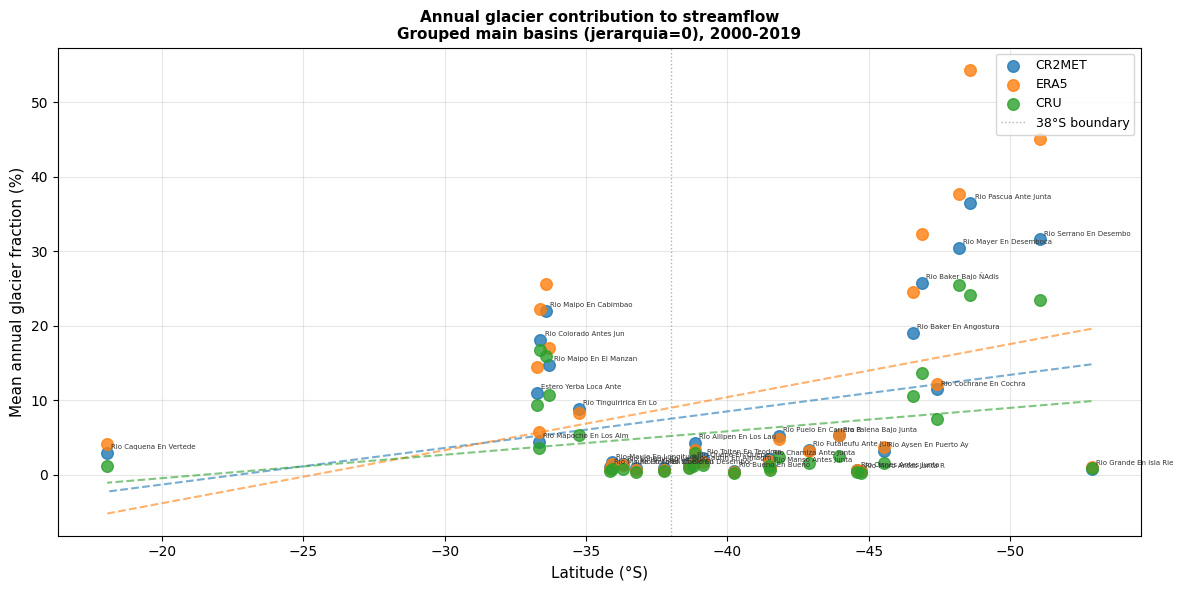

Fig 1 saved


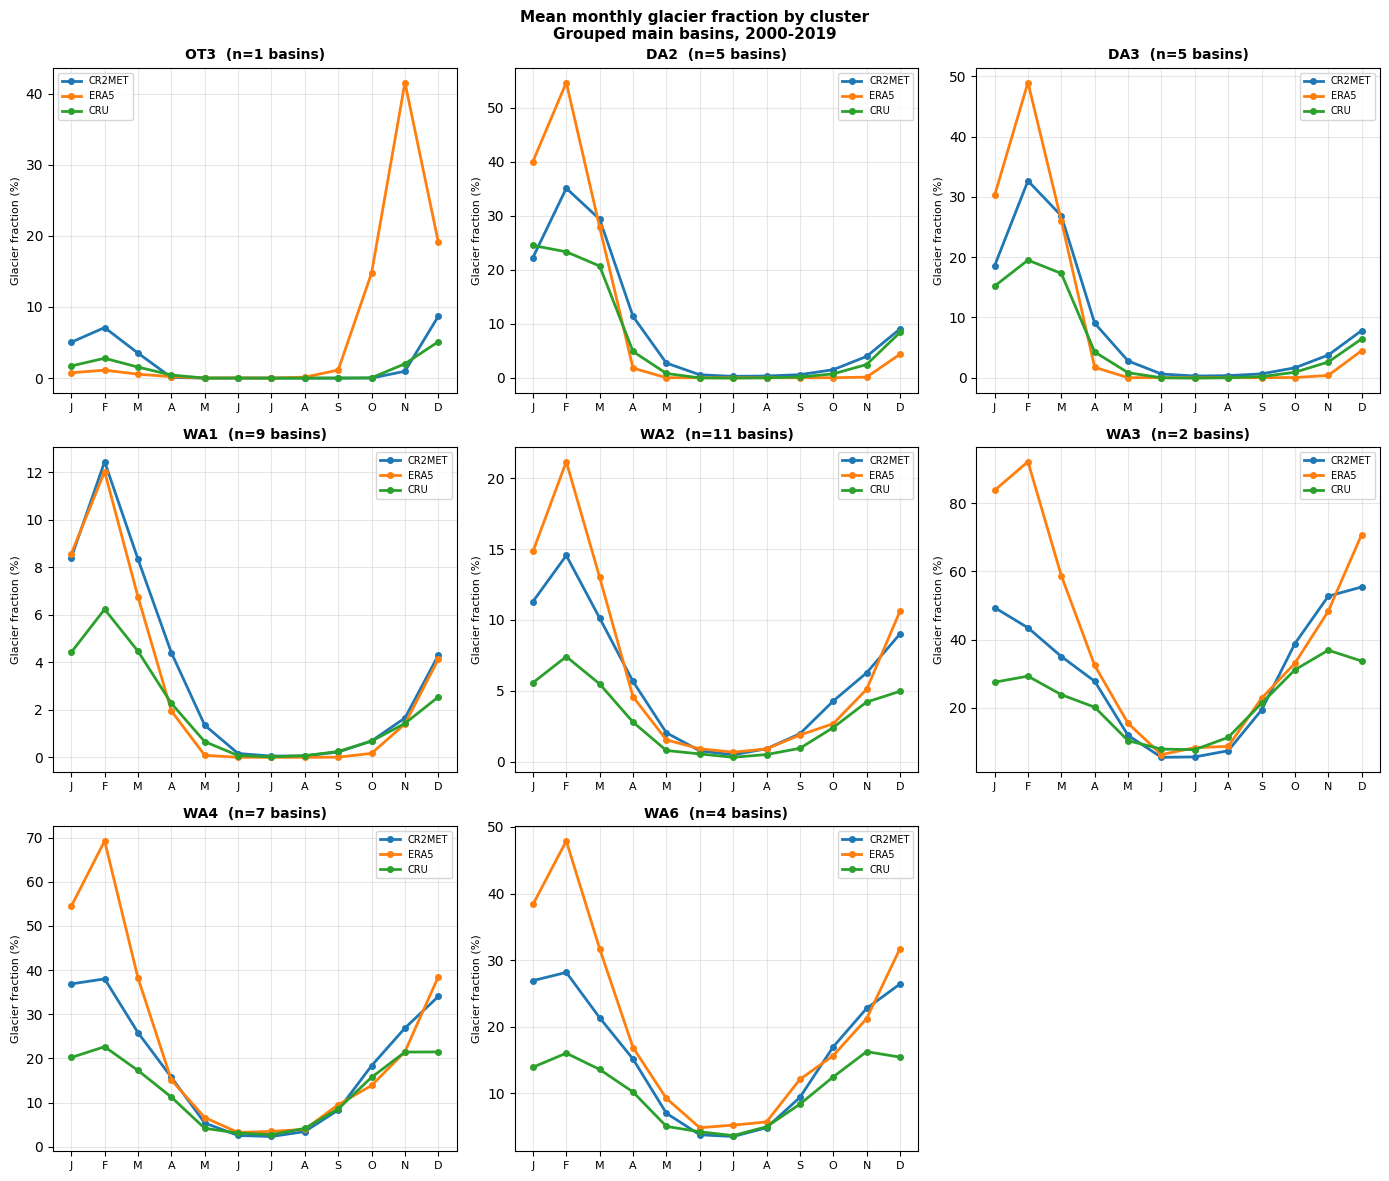

Fig 2 saved


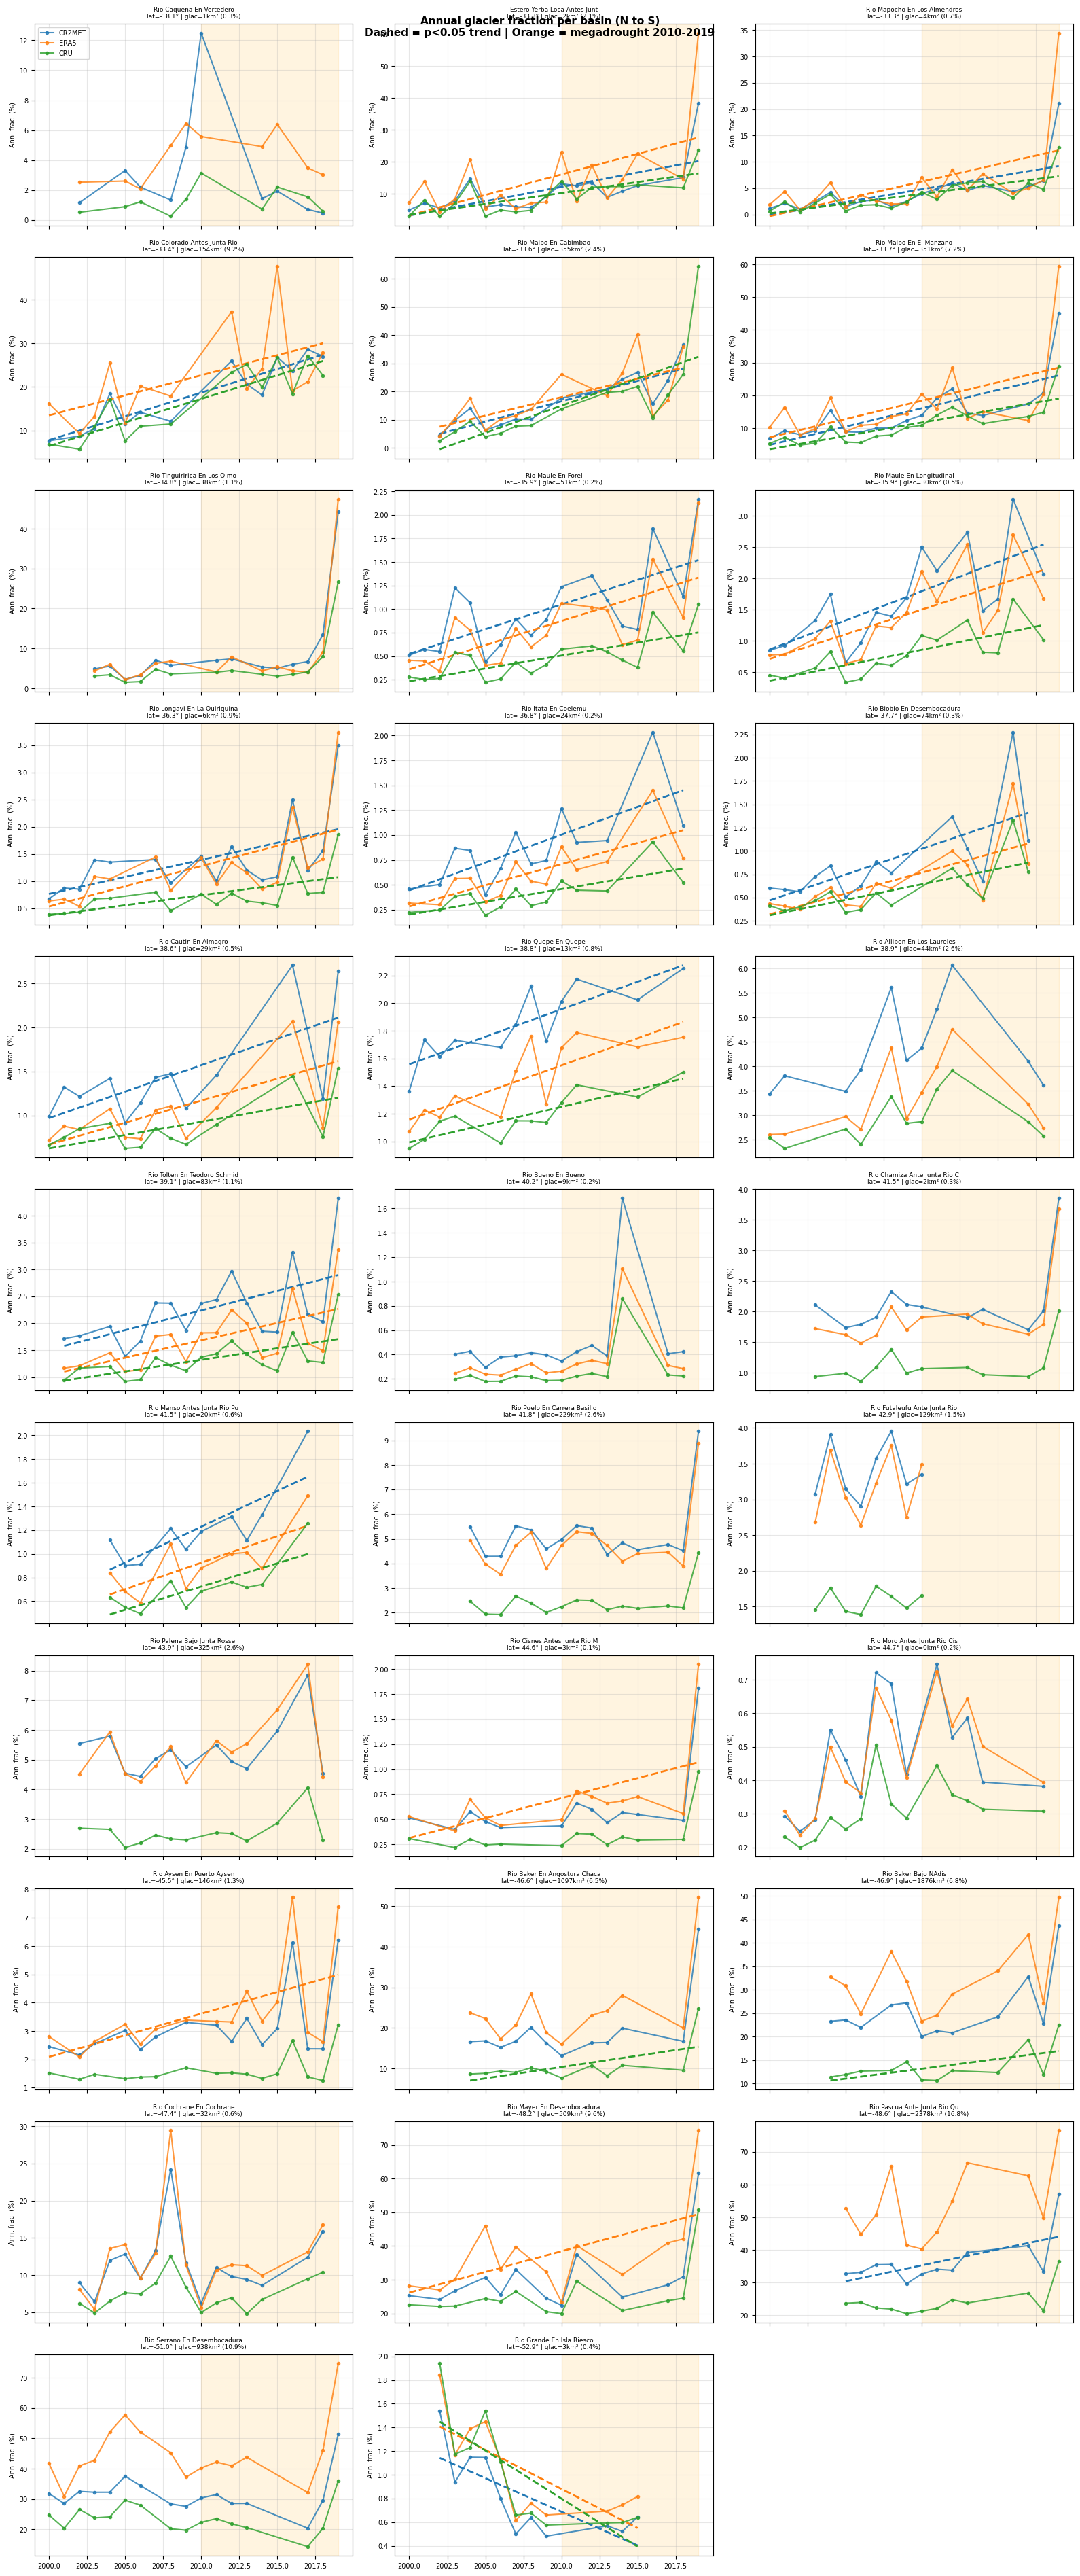

Fig 3 saved

All figures saved to: /Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/grouped_basin_results


In [5]:
# ── Figures: grouped basin analysis ───────────────────────────────────────

DS_COLORS = {'CR2MET': '#1f77b4', 'ERA5': '#ff7f0e', 'CRU': '#2ca02c'}
EXCLUDE   = {'3022001'}  # >100% fraction

valid_gauges = {gid: info for gid, info in GAUGE_INFO_FRAC_GRP.items()
                if gid not in EXCLUDE}
print(f'Valid basins for figures: {len(valid_gauges)}')

# ── Figure 1: Annual fraction vs latitude ─────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

for ds_name in ['CR2MET', 'ERA5', 'CRU']:
    lats, fracs = [], []
    for gid, info in sorted(valid_gauges.items(),
                             key=lambda x: x[1]['cen_lat']):
        res = RESULTS_GRP[ds_name].get(gid)
        if res is None:
            continue
        m   = res['monthly']
        cy  = res['complete_years']
        ann = (m[m['year'].isin(cy)]
               .groupby('year').agg(
                   glac=('glacier_runoff_m3','sum'),
                   q   =('q_m3_mon','sum')))
        ann  = ann[ann['q'] > 0]
        frac = (ann['glac']/ann['q']).mean()*100 if len(ann) else np.nan
        if not np.isnan(frac) and frac <= 100:
            lats.append(info['cen_lat'])
            fracs.append(frac)
    ax.scatter(lats, fracs, color=DS_COLORS[ds_name],
               s=70, alpha=0.8, label=ds_name, zorder=3)
    if len(lats) > 2:
        z  = np.polyfit(lats, fracs, 1)
        xl = np.linspace(min(lats), max(lats), 100)
        ax.plot(xl, np.poly1d(z)(xl), color=DS_COLORS[ds_name],
                lw=1.5, ls='--', alpha=0.6)

# Label basin names on CR2MET points
for gid, info in valid_gauges.items():
    res = RESULTS_GRP['CR2MET'].get(gid)
    if res is None:
        continue
    m   = res['monthly']
    cy  = res['complete_years']
    ann = (m[m['year'].isin(cy)]
           .groupby('year').agg(
               glac=('glacier_runoff_m3','sum'),
               q   =('q_m3_mon','sum')))
    ann  = ann[ann['q'] > 0]
    frac = (ann['glac']/ann['q']).mean()*100 if len(ann) else np.nan
    if not np.isnan(frac) and frac <= 100:
        name = info['gauge_name'][:22]
        ax.annotate(name, (info['cen_lat'], frac),
                    fontsize=5, ha='left', va='bottom',
                    xytext=(3, 2), textcoords='offset points',
                    color='#333333')

ax.axvline(-38, color='gray', lw=1, ls=':', alpha=0.6,
           label='38°S boundary')
ax.invert_xaxis()
ax.set_xlabel('Latitude (°S)', fontsize=11)
ax.set_ylabel('Mean annual glacier fraction (%)', fontsize=11)
ax.set_title('Annual glacier contribution to streamflow\n'
             'Grouped main basins (jerarquia=0), 2000-2019',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR_GRP}/fig1_annual_fraction_latitude.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Fig 1 saved')

# ── Figure 2: Seasonal cycle by cluster ───────────────────────────────────
CLUSTERS_ORDER = ['OT3','DA1','DA2','DA3','WA1',
                  'WA2','WA3','WA4','WA5','WA6']
clusters_present = [cl for cl in CLUSTERS_ORDER
                    if any(cl in info['clusters']
                           for info in valid_gauges.values())]

ncols = 3
nrows = int(np.ceil(len(clusters_present) / ncols))
fig, axes = plt.subplots(nrows, ncols,
                          figsize=(14, nrows * 4), sharey=False)
axes_flat = axes.flatten()
month_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']

for ax_idx, cl in enumerate(clusters_present):
    ax = axes_flat[ax_idx]
    for ds_name in ['CR2MET', 'ERA5', 'CRU']:
        cl_gauges = [gid for gid, info in valid_gauges.items()
                     if cl in info['clusters']]
        mon_fracs = []
        for gid in cl_gauges:
            res = RESULTS_GRP[ds_name].get(gid)
            if res is None:
                continue
            m  = res['monthly']
            cy = res['complete_years']
            mc = m[m['year'].isin(cy) & (m['q_m3_mon'] > 0)].copy()
            if len(mc) == 0:
                continue
            mf = (mc.groupby('month')
                    .apply(lambda g:
                           g['glacier_runoff_m3'].sum() /
                           g['q_m3_mon'].sum()
                           if g['q_m3_mon'].sum() > 0 else np.nan))
            mon_fracs.append(mf)
        if mon_fracs:
            mean_mf = pd.concat(mon_fracs, axis=1).mean(axis=1)
            ax.plot(mean_mf.index, mean_mf.values * 100,
                    color=DS_COLORS[ds_name], lw=2,
                    marker='o', ms=4, label=ds_name)

    n_b = len([g for g, info in valid_gauges.items()
               if cl in info['clusters']])
    ax.set_title(f'{cl}  (n={n_b} basins)',
                 fontsize=10, fontweight='bold')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels, fontsize=8)
    ax.set_ylabel('Glacier fraction (%)', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

for ax in axes_flat[len(clusters_present):]:
    ax.set_visible(False)

fig.suptitle('Mean monthly glacier fraction by cluster\n'
             'Grouped main basins, 2000-2019',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR_GRP}/fig2_seasonal_cycle_by_cluster.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Fig 2 saved')

# ── Figure 3: Annual timeseries per basin ─────────────────────────────────
n_basins = len(valid_gauges)
ncols    = 3
nrows    = int(np.ceil(n_basins / ncols))
fig, axes = plt.subplots(nrows, ncols,
                          figsize=(16, nrows * 3.5), sharex=True)
axes_flat = axes.flatten()

for ax_idx, (gid, info) in enumerate(
        sorted(valid_gauges.items(),
               key=lambda x: x[1]['cen_lat'], reverse=True)):
    ax = axes_flat[ax_idx]
    for ds_name in ['CR2MET', 'ERA5', 'CRU']:
        res = RESULTS_GRP[ds_name].get(gid)
        if res is None:
            continue
        m   = res['monthly']
        cy  = res['complete_years']
        ann = (m[m['year'].isin(cy)]
               .groupby('year').agg(
                   glac=('glacier_runoff_m3','sum'),
                   q   =('q_m3_mon','sum')))
        ann  = ann[ann['q'] > 0]
        frac = ann['glac'] / ann['q'] * 100
        frac = frac[frac <= 100]
        if len(frac) < 3:
            continue
        ax.plot(frac.index, frac.values,
                color=DS_COLORS[ds_name], lw=1.5,
                marker='o', ms=3, alpha=0.8, label=ds_name)
        x = frac.index.astype(float).values
        y = frac.values
        slope, intercept, _, p, _ = stats.linregress(x, y)
        if p < 0.05:
            xl = np.array([x.min(), x.max()])
            ax.plot(xl, slope*xl + intercept,
                    color=DS_COLORS[ds_name], lw=2, ls='--')

    ax.axvspan(2010, 2019, color='orange', alpha=0.12, zorder=0)
    pct = info['glacier_area_km2']/info['basin_area_km2']*100
    ax.set_title(f'{info["gauge_name"][:28]}\n'
                 f'lat={info["cen_lat"]:.1f}° | '
                 f'glac={info["glacier_area_km2"]:.0f}km² ({pct:.1f}%)',
                 fontsize=6.5)
    ax.set_ylabel('Ann. frac. (%)', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)

axes_flat[0].legend(fontsize=7, loc='upper left')
for ax in axes_flat[n_basins:]:
    ax.set_visible(False)

fig.suptitle('Annual glacier fraction per basin (N to S)\n'
             'Dashed = p<0.05 trend | Orange = megadrought 2010-2019',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR_GRP}/fig3_annual_timeseries_per_basin.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Fig 3 saved')
print(f'\nAll figures saved to: {OUT_DIR_GRP}')

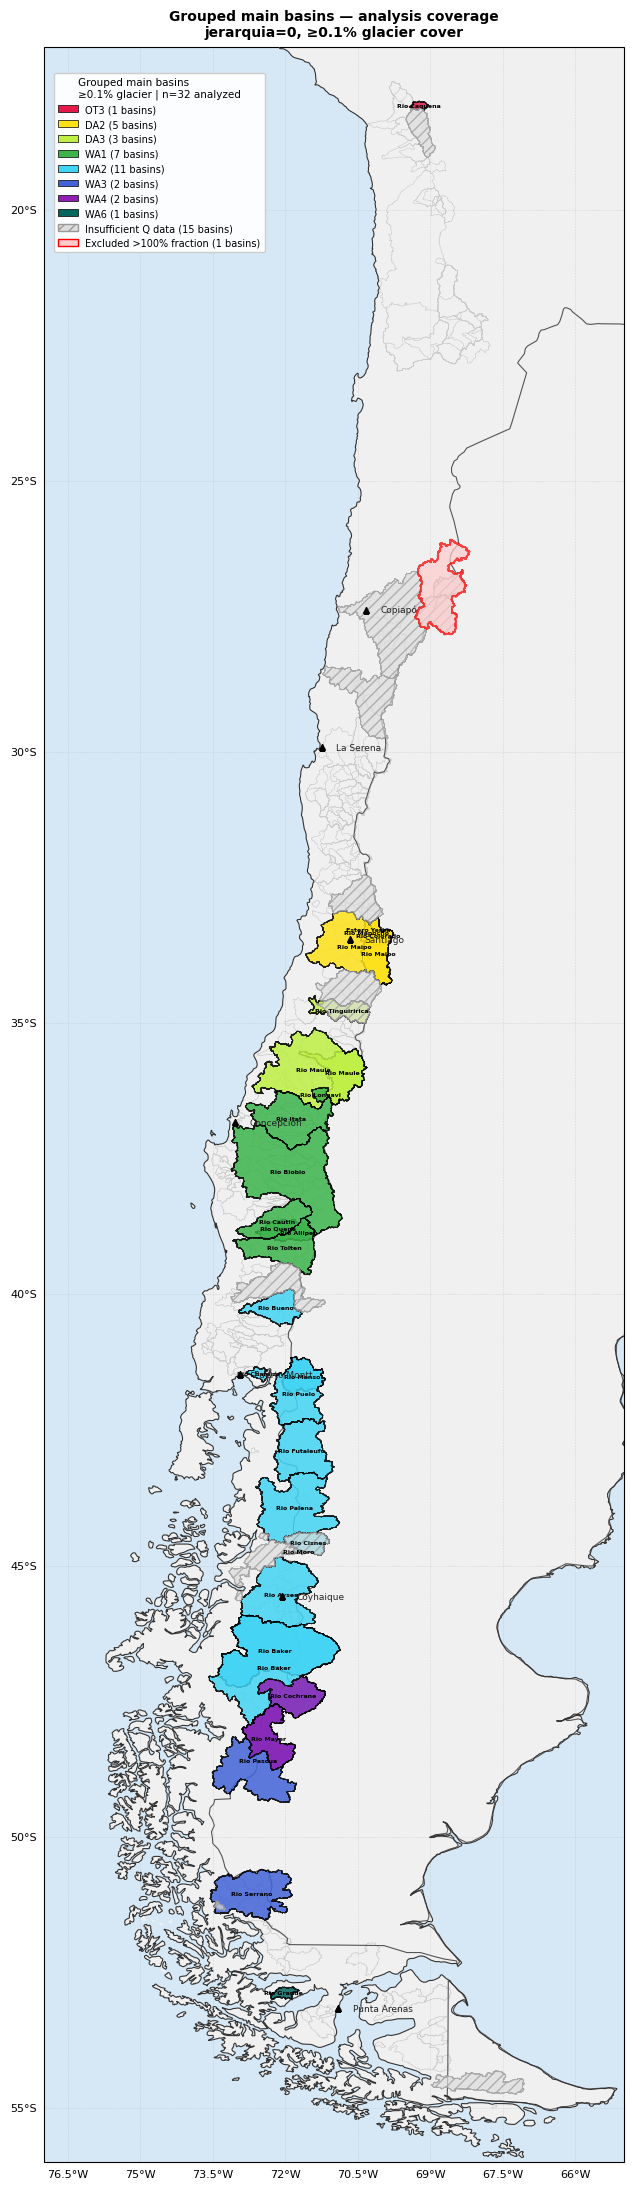

Saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/grouped_basin_results/map_grouped_basins_coverage.png

Summary:
  Included in analysis:      32 basins
  Failed completeness (Q):   15 basins
  Excluded (>100% fraction): 1 basins
  Total glacierized (≥0.1%): 48 basins


In [6]:
# ── Map of grouped basins included in analysis ────────────────────────────

cluster_colors = {
    'OT3': '#e6194b', 'DA1': '#f58231', 'DA2': '#ffe119',
    'DA3': '#bfef45', 'WA1': '#3cb44b', 'WA2': '#42d4f4',
    'WA3': '#4363d8', 'WA4': '#911eb4', 'WA5': '#f032e6',
    'WA6': '#01665e'
}

# Get dominant cluster per basin
def dominant_cluster(clusters):
    for cl in ['OT3','DA1','DA2','DA3','WA1',
               'WA2','WA3','WA4','WA5','WA6']:
        if cl in clusters:
            return cl
    return clusters[0] if clusters else 'unknown'

# Build GeoDataFrame of included basins from main_glacierized
# Flag which ones passed completeness and which failed
included_ids  = set(GAUGE_INFO_FRAC_GRP.keys()) - {'3022001'}
failed_ids    = set(GAUGE_INFO_GROUPED.keys()) - set(GAUGE_INFO_FRAC_GRP.keys())
excluded_ids  = {'3022001'}

main_map = main_glacierized.copy()
main_map['status'] = main_map['gauge_id'].apply(
    lambda x: 'included'  if x in included_ids  else
              'excluded'  if x in excluded_ids   else
              'no_q_data')
main_map['cluster'] = main_map['clusters'].apply(dominant_cluster)

# ── Figure ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(9, 22))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([-77, -65, -56, -17], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.OCEAN,     facecolor='#d6e8f5', zorder=0)
ax.add_feature(cfeature.LAND,      facecolor='#f0f0f0', zorder=0)

# All CAMELS boundaries — grey context
bounds.plot(ax=ax, facecolor='none', edgecolor='#cccccc',
            linewidth=0.3, zorder=1)

# Argentina border
try:
    world = gpd.read_file(
        'https://naturalearth.s3.amazonaws.com/50m_cultural/'
        'ne_50m_admin_0_countries.zip')
    world[world['NAME'] == 'Argentina'].plot(
        ax=ax, facecolor='none', edgecolor='#555555',
        linewidth=0.8, zorder=2,
        transform=ccrs.PlateCarree())
except Exception:
    pass

# Included basins — colored by dominant cluster
for cl, color in cluster_colors.items():
    subset = main_map[(main_map['cluster'] == cl) &
                      (main_map['status'] == 'included')]
    if len(subset) == 0:
        continue
    subset.plot(ax=ax, facecolor=color, edgecolor='k',
                linewidth=0.6, alpha=0.85, zorder=3)

# Failed completeness — hatched grey
no_q = main_map[main_map['status'] == 'no_q_data']
if len(no_q):
    no_q.plot(ax=ax, facecolor='#dddddd', edgecolor='#999999',
              linewidth=0.5, alpha=0.7, zorder=3, hatch='///')

# Excluded >100% — red outline
excl = main_map[main_map['status'] == 'excluded']
if len(excl):
    excl.plot(ax=ax, facecolor='#ffcccc', edgecolor='red',
              linewidth=1.0, alpha=0.7, zorder=3)

# Coastline
ax.add_feature(cfeature.COASTLINE, linewidth=0.8,
               edgecolor='#333333', zorder=4)

# Basin labels
for _, row in main_map.iterrows():
    if row['status'] == 'included':
        centroid = row.geometry.centroid
        name     = str(row.get('gauge_name', row['gauge_id']))
        # Short label: first two words
        short    = ' '.join(name.split()[:2])
        ax.text(centroid.x, centroid.y, short,
                fontsize=4.5, ha='center', va='center',
                color='k', fontweight='bold', zorder=5,
                transform=ccrs.PlateCarree())

# Key cities
cities = {
    'Santiago':     (-33.45, -70.67),
    'Concepción':   (-36.82, -73.05),
    'Puerto Montt': (-41.47, -72.94),
    'Coyhaique':    (-45.57, -72.07),
    'Punta Arenas': (-53.16, -70.91),
    'La Serena':    (-29.91, -71.25),
    'Copiapó':      (-27.37, -70.33),
}
for city, (lat, lon) in cities.items():
    ax.plot(lon, lat, 'k^', markersize=5, zorder=6,
            transform=ccrs.PlateCarree())
    ax.text(lon + 0.3, lat, city, fontsize=6.5,
            va='center', color='#222222', zorder=6,
            transform=ccrs.PlateCarree())

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.4,
                  alpha=0.4, linestyle='--')
gl.top_labels   = False
gl.right_labels = False
gl.xlabel_style = {'size': 8}
gl.ylabel_style = {'size': 8}

# Legend
legend_handles = []
for cl in ['OT3','DA1','DA2','DA3','WA1',
           'WA2','WA3','WA4','WA5','WA6']:
    n = len(main_map[(main_map['cluster'] == cl) &
                     (main_map['status'] == 'included')])
    if n == 0:
        continue
    legend_handles.append(mpatches.Patch(
        facecolor=cluster_colors[cl], edgecolor='k',
        linewidth=0.5, label=f'{cl} ({n} basins)'))

legend_handles.append(mpatches.Patch(
    facecolor='#dddddd', edgecolor='#999999',
    hatch='///', label=f'Insufficient Q data ({len(no_q)} basins)'))

if len(excl):
    legend_handles.append(mpatches.Patch(
        facecolor='#ffcccc', edgecolor='red',
        label=f'Excluded >100% fraction ({len(excl)} basins)'))

ax.legend(handles=legend_handles, loc='upper left',
          fontsize=7, framealpha=0.93,
          title=f'Grouped main basins\n≥0.1% glacier | n={len(included_ids)} analyzed',
          title_fontsize=7.5,
          bbox_to_anchor=(0.01, 0.99))

ax.set_title('Grouped main basins — analysis coverage\n'
             'jerarquia=0, ≥0.1% glacier cover',
             fontsize=10, fontweight='bold', pad=8)

plt.tight_layout()
out = f'{OUT_DIR_GRP}/map_grouped_basins_coverage.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

# Print summary
print(f'\nSummary:')
print(f'  Included in analysis:      {len(included_ids)} basins')
print(f'  Failed completeness (Q):   {len(failed_ids)} basins')
print(f'  Excluded (>100% fraction): {len(excluded_ids)} basins')
print(f'  Total glacierized (≥0.1%): {len(main_map)} basins')